In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from IPython.display import display, HTML

### ✅ GPU Compute Benchmark란?

**GPU Compute Benchmark**는 PassMark의 PerformanceTest에서 제공하는 벤치마크로,  
OpenCL과 DirectCompute 같은 범용 GPU 연산(GPGPU) 환경에서 그래픽카드의 **실제 계산 성능**을 측정한 지표입니다.  
수백만 건의 테스트 결과를 기반으로 매일 업데이트되며, GPU가 병렬 연산 환경에서 얼마나 효율적으로 작동하는지를 나타냅니다.

- **OpenCL**: Khronos Group이 만든 범용 병렬 컴퓨팅 프레임워크  
- **DirectCompute**: Microsoft의 DirectX API 중 하나로, GPU에서 CPU처럼 범용 계산 수행  
- 두 방식 모두 **실제 연산 속도는 유사**하며, 이 벤치마크는 두 결과를 모두 반영하여 성능을 점수화합니다.

> 따라서, 이 벤치마크 점수는 GPU가 **실제 환경에서 어느 정도 계산 능력을 발휘하는지**를 보여주는 **현실적인 성능 지표**로 활용할 수 있습니다.

※ 이 기준은 [PassMark Software](https://www.passmark.com) 공식 GPU Compute Benchmark 페이지에서 제시한 내용을 기반으로 정리하였습니다.

---

### 📌 기타 GPU 스펙 정보 출처

이 프로젝트에서 사용된 **GPU의 기본적인 스펙 정보**는  
[TechPowerUp GPU Database](https://www.techpowerup.com/gpu-specs/)에서 크롤링한 데이터를 기반으로 수집되었습니다.

TechPowerUp은 다양한 GPU의 구조적 사양을 체계적으로 정리한 데이터베이스를 제공하는 사이트로, 모델별 세부 성능 및 하드웨어 정보를 확인할 수 있습니다..

In [2]:
# 데이터 불러오기
df_spec = pd.read_csv("./Nvidia_gpu_crawled_details.csv")
df_score = pd.read_csv("./gpu_scores.csv")

display(df_spec.shape)
display(df_spec.head())

display(df_score.shape)
display(df_score.head())

(1415, 75)

,Model Name,GPU Name,Architecture,Foundry,Process Size,Transistors,Density,Die Size,Release Date,Generation,...,Storage,Tensor Cores,RT Cores,BF16,TF32,FP64 Tensor,NVENC,NVDEC,Process Type,Announced
0,GeForce 256 DDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Dec 23rd, 1999",GeForce 256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GeForce 256 SDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Oct 11th, 1999",GeForce 256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Quadro,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,1999,Quadro Celsius,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Riva TNT2,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Riva TNT2 M64,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(1560, 2)

,Model Name,Score
0,GeForce RTX 4090,27172.0
1,RTX 6000 Ada Generation,24403.0
2,GeForce RTX 5090,23406.0
3,GeForce RTX 4080,21034.0
4,RTX 5000 Ada Generation,20708.0


In [3]:
# 모델명 전처리 함수 (소문자 + 공백 제거)
def clean_name(name):
    return ''.join(str(name).lower().split())

# 비교용 모델명 컬럼 생성
df_spec['model_clean'] = df_spec['Model Name'].apply(clean_name)
df_score['model_clean'] = df_score['Model Name'].apply(clean_name)

# 병합 (spec 기준으로 score 추가)
df = pd.merge(df_spec, df_score.drop(columns='Model Name'), on='model_clean', how='left')

# 비교용 컬럼 제거
df.drop(columns='model_clean', inplace=True)

# 결과 확인
df.head()

,Model Name,GPU Name,Architecture,Foundry,Process Size,Transistors,Density,Die Size,Release Date,Generation,...,Tensor Cores,RT Cores,BF16,TF32,FP64 Tensor,NVENC,NVDEC,Process Type,Announced,Score
0,GeForce 256 DDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Dec 23rd, 1999",GeForce 256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GeForce 256 SDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Oct 11th, 1999",GeForce 256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Quadro,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,1999,Quadro Celsius,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Riva TNT2,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Riva TNT2 M64,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# 출력 생략 방지를 위한 설정
pd.set_option('display.max_rows', 100)     # 최대 100행까지 출력
pd.set_option('display.max_columns', 100)  # 최대 100열까지 출력
pd.set_option('display.max_colwidth', 200) # 한 셀에 출력되는 최대 글자 수

In [5]:
# 상위 5개 행 확인
print("🔹 데이터 미리보기:")
display(df.head())

# 데이터프레임 정보 확인
print("\n🔹 데이터 요약 정보:")
df.info()

# 결측치 개수 확인
print("\n🔹 결측치 개수:")
print(df.isnull().sum())

# 기술통계 (수치형 변수 기준)
print("\n🔹 수치형 변수 통계:")
display(df.describe())

# 범주형 변수 비율 확인
print("\n🔹 범주형 변수 값 분포 예시:")
for col in df.select_dtypes(include='object').columns[:5]:
    print(f"\n▶ {col}")
    print(df[col].value_counts().head())

🔹 데이터 미리보기:


,Model Name,GPU Name,Architecture,Foundry,Process Size,Transistors,Density,Die Size,Release Date,Generation,Predecessor,Successor,Production,Bus Interface,Reviews,GPU Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,Pixel Shaders,Vertex Shaders,TMUs,ROPs,Pixel Rate,Texture Rate,Slot Width,TDP,Suggested PSU,Outputs,Power Connectors,DirectX,OpenGL,OpenCL,Vulkan,Pixel Shader,Vertex Shader,URL,Launch Price,GPU Variant,Board Number,Length,Vertex Rate,Width,Height,Weight,Chip Package,Shader Model,Shader Clock,Shading Units,SM Count,L2 Cache,FP32 (float),CUDA,Base Clock,Boost Clock,CUDA SDK,FP64 (double),Availability,L1 Cache,SMX Count,SMM Count,FP16 (half),Current Price,Storage,Tensor Cores,RT Cores,BF16,TF32,FP64 Tensor,NVENC,NVDEC,Process Type,Announced,Score
0,GeForce 256 DDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Dec 23rd, 1999",GeForce 256,TNT2,GeForce 2,End-of-life,AGP 4x,1 in our database,120 MHz,150 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t300 Mbps effective,32 MB,DDR,128 bit,4.800 GB/s,4.0,0.0,4.0,4.0,480.0 MPixel/s,480.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/geforce-256-ddr.c734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GeForce 256 SDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Oct 11th, 1999",GeForce 256,TNT2,GeForce 2,End-of-life,AGP 4x,1 in our database,120 MHz,143 MHz,32 MB,SDR,64 bit,1.144 GB/s,4.0,0.0,4.0,4.0,480.0 MPixel/s,480.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/geforce-256-sdr.c731,249 USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Quadro,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,1999,Quadro Celsius,NaN,Quadro2 Celcius,End-of-life,AGP 4x,26 in our database,135 MHz,166 MHz,32 MB,SDR,128 bit,2.656 GB/s,4.0,0.0,4.0,4.0,540.0 MPixel/s,540.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/quadro.c1374,NaN,NV10GL A3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Riva TNT2,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,Riva,GeForce 256,End-of-life,AGP 4x,1 in our database,125 MHz,150 MHz,16 MB,SDR,128 bit,2.400 GB/s,2.0,0.0,2.0,2.0,250.0 MPixel/s,250.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,6.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/riva-tnt2.c4130,NaN,Riva TNT2,22230350-005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Riva TNT2 M64,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,Riva,GeForce 256,End-of-life,AGP 4x,1 in our database,125 MHz,143 MHz,16 MB,SDR,64 bit,1.144 GB/s,2.0,0.0,2.0,2.0,250.0 MPixel/s,250.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,6.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/riva-tnt2-m64.c1304,NaN,Riva TNT2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



🔹 데이터 요약 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 76 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Model Name        1417 non-null   object 
 1   GPU Name          1417 non-null   object 
 2   Architecture      1417 non-null   object 
 3   Foundry           1363 non-null   object 
 4   Process Size      1417 non-null   object 
 5   Transistors       1417 non-null   object 
 6   Density           1393 non-null   object 
 7   Die Size          1417 non-null   object 
 8   Release Date      1417 non-null   object 
 9   Generation        1417 non-null   object 
 10  Predecessor       1252 non-null   object 
 11  Successor         1229 non-null   object 
 12  Production        1417 non-null   object 
 13  Bus Interface     1410 non-null   object 
 14  Reviews           682 non-null    object 
 15  GPU Clock         829 non-null    object 
 16  Memory Clock      1417 non-n

,Pixel Shaders,Vertex Shaders,TMUs,ROPs,Shading Units,SM Count,CUDA,CUDA SDK,SMX Count,SMM Count,Tensor Cores,RT Cores,Score
count,319.000000,319.000000,1417.000000,1417.000000,1098.000000,834.000000,1070.000000,12.0,165.000000,99.000000,264.000000,207.000000,385.000000
mean,7.442006,2.996865,72.700776,29.056457,1804.983607,22.973621,4.411215,6.5,5.303030,7.535354,274.060606,47.130435,2846.257143
std,7.480095,2.739759,101.016833,34.343083,3055.873330,29.522153,2.824933,0.0,4.392933,5.916620,178.519461,28.414023,4385.592689
min,2.000000,0.000000,1.000000,1.000000,8.000000,1.000000,1.000000,6.5,1.000000,1.000000,16.000000,6.000000,9.000000
25%,2.000000,1.000000,8.000000,4.000000,96.000000,3.000000,2.000000,6.5,2.000000,3.000000,120.000000,28.000000,472.000000
50%,4.000000,3.000000,32.000000,16.000000,448.000000,12.000000,3.500000,6.5,4.000000,5.000000,240.000000,40.000000,1000.000000
75%,8.000000,5.000000,80.000000,32.000000,2304.000000,30.000000,7.500000,6.5,8.000000,10.000000,388.000000,58.000000,2808.000000
max,48.000000,24.000000,576.000000,192.000000,18432.000000,144.000000,10.100000,6.5,15.000000,24.000000,640.000000,144.000000,27172.000000



🔹 범주형 변수 값 분포 예시:

▶ Model Name
Model Name
ION                   5
GeForce GT 635M       4
GeForce 6800 XT       4
GeForce 6800 GT       3
GeForce GT 330 OEM    3
Name: count, dtype: int64

▶ GPU Name
GPU Name
GK104    51
GK107    47
GF108    38
GM107    30
GA107    28
Name: count, dtype: int64

▶ Architecture
Architecture
Tesla     177
Curie     168
Kepler    137
Ampere    120
Pascal     94
Name: count, dtype: int64

▶ Foundry
Foundry
TSMC       1196
Samsung     135
UMC          28
Sony          4
Name: count, dtype: int64

▶ Process Size
Process Size
28 nm    282
40 nm    219
12 nm    114
8 nm     101
90 nm     89
Name: count, dtype: int64


In [6]:
# 타겟 변수 'Score'를 기준으로 결측 행 제거
initial_shape = df.shape
df = df[df["Score"].notnull()]
removed_score_rows = initial_shape[0] - df.shape[0]
print(f"🧹 'Score' 결측으로 제거된 행 수: {removed_score_rows}\n")

🧹 'Score' 결측으로 제거된 행 수: 1032



In [7]:
# 결측 비율 계산
col_null_ratio = df.isnull().mean()

# 하나의 DataFrame으로 정리
null_summary = pd.DataFrame({
    "MissingRatio": col_null_ratio,
    "Over50%": col_null_ratio >= 0.5,
    "Over70%": col_null_ratio >= 0.7
}).sort_values("MissingRatio", ascending=False)

# 결측 비율이 0.5보다 큰 컬럼만 보기
display(null_summary[null_summary["MissingRatio"] > 0.5])

# 70% 이상 결측 컬럼 제거
cols_to_drop_50 = null_summary[null_summary["Over50%"]].index
df = df.drop(columns=cols_to_drop_50)

print(f"\n🧹 50% 이상 결측 컬럼 제거 완료! 제거된 컬럼 수: {len(cols_to_drop_50)}")

print(f"\n🧹 50% 이상 70% 미만 결측 컬럼")
# 결측 비율이 50% 이상 70% 미만인 컬럼만 보기
display(null_summary[(null_summary["MissingRatio"] >= 0.5) & (null_summary["MissingRatio"] < 0.7)])

,MissingRatio,Over50%,Over70%
Vertex Rate,1.000000,True,True
TF32,1.000000,True,True
Pixel Shaders,1.000000,True,True
Weight,1.000000,True,True
Storage,1.000000,True,True
Pixel Shader,1.000000,True,True
BF16,1.000000,True,True
Vertex Shaders,1.000000,True,True
FP64 Tensor,1.000000,True,True
NVENC,1.000000,True,True



🧹 50% 이상 결측 컬럼 제거 완료! 제거된 컬럼 수: 29

🧹 50% 이상 70% 미만 결측 컬럼


,MissingRatio,Over50%,Over70%
Shader Clock,0.677922,True,False
Width,0.667532,True,False
Power Connectors,0.651948,True,False
Launch Price,0.633766,True,False
GPU Clock,0.589610,True,False
Reviews,0.545455,True,False


### 🔍 결측률 50% 이상 70% 미만 컬럼 제거 사유

다음 컬럼들은 결측률이 50% 이상이지만 70% 미만으로, 완전 삭제를 망설일 수 있는 범위입니다. 그러나 **벤치마크 점수(`Score`) 예측이라는 분석 목적**과의 관련성이 낮거나 불확실하여 제거 대상으로 판단했습니다.

| 변수명 | 결측률 | 설명 | 제거 사유 |
|--------|--------|------|------------|
| **Shader Clock** | 67.8% | GPU의 쉐이더 클럭 속도 (과거에는 중요했으나 현재는 잘 사용되지 않음) | 현대 GPU에서는 Boost Clock 위주로 동작하며, Shader Clock은 명확하지 않거나 측정 불가한 경우가 많아 성능 예측 변수로서 부적절 |
| **Width** | 66.8% | 메모리 인터페이스 폭 (ex. 128-bit, 256-bit) | 메모리 대역폭의 일부를 구성하지만, 대역폭 전체와 DRAM 종류, 캐시 구조 등 복합 요소가 성능에 영향을 주므로 단독으로 쓰기 어려움 |
| **Power Connectors** | 65.2% | 보조 전원 커넥터 수 및 타입 (예: 6-pin, 8-pin) | 전력 공급 한계는 나타내지만, 아키텍처에 따라 전력 효율이 다르기 때문에 `Score`와 직접적 상관이 낮음 |
| **Launch Price** | 63.4% | 출시 당시 가격 (달러 기준) | 가격은 시장 포지셔닝과 브랜드 전략에 따라 결정되므로, 성능과 반드시 비례하지 않음 |
| **GPU Clock** | 58.9% | GPU의 기본 클럭 속도 (MHz) | 실제 성능은 Boost Clock 및 병렬 구조에 더 좌우되므로 단독으로는 예측력 낮음 |
| **Reviews** | 54.5% | 유저/매체의 리뷰 수 | 주관적 평가는 벤치마크 점수의 정량적 수치와 무관하며, 누락된 값도 많고 일관성 부족 |

> 🔎 이 컬럼들은 대부분 구형 GPU에서의 측정 누락 또는 현대 GPU에서의 비활성화된 개념이며, 결측률이 높아 학습 데이터의 불확실성을 높이므로 **모델의 일반화 성능에 부정적 영향을 줄 수 있어 제거**는 것이 합리적입니다.


In [8]:
# ✅ 추가 결측 제거 이후, 데이터 상태 다시 점검

# 데이터프레임 정보 확인
print("\n🔹 [After Drop] 데이터 요약 정보:")
df.info()

# 결측치 개수 확인
print("\n🔹 [After Drop] 컬럼별 결측치 개수:")
print(df.isnull().sum())

df.to_csv('확인용_70_컬럼제거이후.csv', index=False)


🔹 [After Drop] 데이터 요약 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 385 entries, 263 to 1416
Data columns (total 47 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model Name     385 non-null    object 
 1   GPU Name       385 non-null    object 
 2   Architecture   385 non-null    object 
 3   Foundry        381 non-null    object 
 4   Process Size   385 non-null    object 
 5   Transistors    385 non-null    object 
 6   Density        385 non-null    object 
 7   Die Size       385 non-null    object 
 8   Release Date   385 non-null    object 
 9   Generation     385 non-null    object 
 10  Predecessor    340 non-null    object 
 11  Successor      336 non-null    object 
 12  Production     385 non-null    object 
 13  Bus Interface  385 non-null    object 
 14  Memory Clock   385 non-null    object 
 15  Memory Size    385 non-null    object 
 16  Memory Type    385 non-null    object 
 17  Memory Bus     385 non-null  

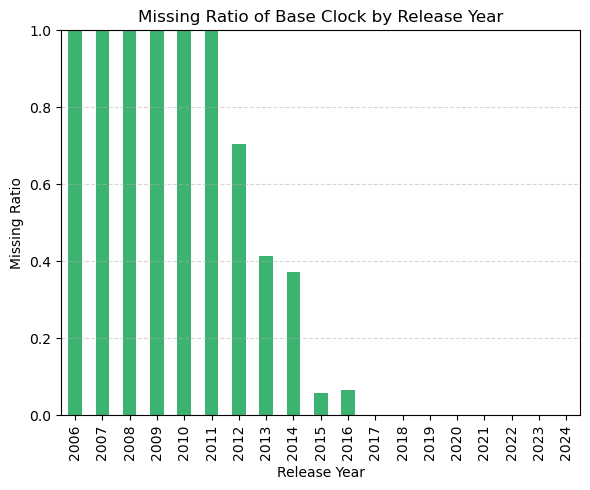

In [9]:
# 날짜 문자열을 datetime으로 변환하고 연도 추출
df['Release_Year'] = pd.to_datetime(df['Release Date'], errors='coerce').dt.year

# 연도별 Base Clock 결측 비율 계산
yearly_null_ratio = df.groupby('Release_Year')['Base Clock'].apply(lambda x: x.isnull().mean())

# ⚠️ Base Clock은 임의 보간이 어려운 GPU 핵심 스펙 중 하나
# 최신 GPU로 갈수록 해당 정보가 잘 기록되는 경향이 있으며,
# 이는 미래 세대 예측의 현실적인 특성을 반영하므로 해당 변수를 기준으로 데이터를 보존하여 분석

plt.figure(figsize=(6, 5))
yearly_null_ratio.plot(kind='bar', color='#3CB371')
plt.title('Missing Ratio of Base Clock by Release Year')
plt.ylabel('Missing Ratio')
plt.xlabel('Release Year')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 연도 레이블을 정수로 표시
plt.xticks(ticks=range(len(yearly_null_ratio)), labels=yearly_null_ratio.index.astype('Int64'))

plt.tight_layout()
plt.show()

In [10]:
# Base Clock이 결측된 행들(n=158)은 Boost Clock(100%)을 비롯해, L1 Cache(~51%) 등 다른 성능 변수들도 누락
# 이런 행들은 대부분 오래된 GPU로, 정보 자체가 기록되어 있지 않아 크롤링 과정에서도 얻을 수 없었음
# 따라서 본 분석에서는 신뢰 가능한 성능 데이터를 기반으로 하기 위해, Base Clock이 결측인 행은 모두 제거

# Base Clock이 결측인 행만 필터링
missing_base_clock = df[df["Base Clock"].isnull()]
print(f"⚠️ Base Clock 결측 행 수: {len(missing_base_clock)}")

# Base Clock이 결측인 행들에 대해서 각 컬럼별 결측 비율 계산 (결측이 전혀 없는 컬럼은 제외)
null_ratio = missing_base_clock.isnull().mean()
non_zero_nulls = null_ratio[null_ratio > 0].sort_values(ascending=False)

# 결측 비율이 존재하는 컬럼만 출력
display(non_zero_nulls)

# Base Clock이 결측인 행 제거
df = df[df["Base Clock"].notnull()]
print(f"\n🧹 Base Clock 결측 행 제거 후 행의 수: {len(df)}")

df.to_csv('확인용_BaseClock_결측제거이후.csv', index=False)

⚠️ Base Clock 결측 행 수: 158


Boost Clock      1.000000
Base Clock       1.000000
Vulkan           0.778481
Length           0.544304
Suggested PSU    0.487342
Board Number     0.417722
Release_Year     0.373418
SM Count         0.221519
GPU Variant      0.202532
Predecessor      0.145570
Successor        0.145570
FP64 (double)    0.132911
L1 Cache         0.120253
Slot Width       0.044304
Chip Package     0.031646
OpenCL           0.025316
L2 Cache         0.025316
CUDA             0.025316
Foundry          0.025316
dtype: float64


🧹 Base Clock 결측 행 제거 후 행의 수: 227


In [11]:
# 💡 열 기준 결측 비율 재계산
# 이전 단계에서 70% 이상 결측된 컬럼을 제거한 바 있으나,
# Base Clock 결측 행 제거 이후 데이터의 결측 분포가 달라졌을 가능성이 있음.
# 따라서 보다 보수적인 기준(40%)을 적용하여 결측 컬럼을 추가로 제거함.

# 📌 열 기준 결측 비율 계산, 40% 이상 결측 컬럼 미리 확인
col_null_ratio = df.isnull().mean().sort_values(ascending=False)
cols_to_drop_50 = col_null_ratio[col_null_ratio > 0.4].index

# 제거 대상 컬럼 확인
display(col_null_ratio[col_null_ratio > 0.4])
print(f"\n🧹 40% 이상 결측된 컬럼 수: {len(cols_to_drop_50)}")
print(f"👉 제거 대상 컬럼 목록:\n{list(cols_to_drop_50)}")

# 컬럼 제거 실행
df = df.drop(columns=cols_to_drop_50)

SM Count         0.533040
Length           0.427313
Suggested PSU    0.414097
dtype: float64


🧹 40% 이상 결측된 컬럼 수: 3
👉 제거 대상 컬럼 목록:
['SM Count', 'Length', 'Suggested PSU']


### 🔍 GPU 변수별 결측치 및 활용 판단 요약

| 변수명            | 의미                         | 결측치 개수 | 활용 판단 | 판단 근거 |
|------------------|------------------------------|-------------|-----------|-----------|
| Model Name       | 제품 모델명                  | 0           | 필요      | 기본 식별 정보로 반드시 필요, 학습시에는 잠시 드랍 |
| GPU Name         | GPU 칩 이름                  | 0           | 불필요    | 칩셋 기준 구분에 사용 -> 중요한 피쳐이나, 유니크값이 57개. 그외 정량적 수치 있으므로 제외 |
| Architecture     | GPU 아키텍처 명칭            | 0           | 불필요    | 세대에 따라 변화하는 구조이나 수치화 어려움, 구조적 성능 정보 부족 |
| Foundry          | 제조사(파운드리)             | 0           | 필요      | 기술력 및 세대 구분 참고 -> 바이너리 처리 가능 |
| Process Size     | 공정 크기 (nm)               | 0           | 필요      | 성능/전력 효율과 직접 관련 |
| Transistors      | 트랜지스터 개수              | 0           | 필요      | 성능 수준 비교에 활용 |
| Density          | 트랜지스터 밀도              | 0           | 필요      | 제조 효율성과 성능에 영향 |
| Die Size         | 다이 면적 (mm²)              | 0           | 필요      | 공정 밀도 및 기술력 평가에 유용 |
| Release Date     | 출시일                       | 0           | 불필요    | 기술 발전에 따른 성능 편향 유발, 현재 분석 취지에 맞지 않음 |
| Generation       | 세대 구분                    | 0           | 불필요    | 위와 같은 이유로 제외 |
| Predecessor      | 전 세대 모델                 | 22          | 불필요    | 모델 간 연결 정보는 분석 가치 낮음 |
| Successor        | 후속 모델                    | 26          | 불필요    | 위와 같음 |
| Production       | 생산 상태 (단종 여부 등)     | 0           | 불필요    | 시장 유통 여부는 현재 분석과 관련 없음 |
| Bus Interface    | 인터페이스 종류              | 0           | 불필요    | 해석 복잡 + 성능 기여도 낮음 -> 회귀 잡음 유발 가능 |
| Memory Clock     | 메모리 클럭                  | 0           | 필요      | 메모리 성능에 직접 영향 |
| Memory Size      | 메모리 용량                  | 0           | 필요      | 메모리 사양 중 핵심 지표 |
| Memory Type      | 메모리 종류 (GDDR6 등)       | 0           | 필요      | 성능 구분에 핵심적인 분류 기준 |
| Memory Bus       | 메모리 버스 폭 (bit)         | 0           | 필요      | 대역폭과 직접적인 상관 관계 |
| Bandwidth        | 메모리 대역폭 (GB/s)         | 0           | 필요      | 전송 속도 평가의 핵심 지표 |
| TMUs             | 텍스처 매핑 유닛 수          | 0           | 필요      | 그래픽 처리 성능에 영향 |
| ROPs             | 렌더 출력 유닛 수            | 0           | 필요      | 렌더링 성능 판단 기준 |
| Pixel Rate       | 픽셀 처리 속도               | 0           | 필요      | 픽셀 렌더링 성능 관련 |
| Texture Rate     | 텍스처 처리 속도             | 0           | 필요      | TMU 성능과 관련된 지표 |
| Slot Width       | 장착 슬롯 형태 및 크기        | 5           | 필요      | 고성능 GPU일수록 Dual 이상 슬롯 많음 -> 분류 지표로 활용 가능 |
| TDP              | 열 설계 전력 (W)             | 0           | 필요      | 전력 효율 및 발열 관리에 필수 |
| Outputs          | 출력 포트 구성               | 0           | 불필요    | 활용 목적(게이밍/워크스테이션 등)에 가까움 |
| DirectX          | 지원 DirectX 버전            | 0           | 불필요      | 지원 버전은 거의 항상 GPU 세대 반영이라 성능 향상 트렌드 반영 가능성 높음. 구조적 성능보다 “시대 흐름”에 가까움 |
| OpenGL           | 지원 OpenGL 버전             | 0           | 불필요    | 위와 같음 |
| OpenCL           | 지원 OpenCL 버전             | 0           | 불필요      | 위와 같음 |
| Vulkan           | 지원 Vulkan 버전             | 1           | 불필요    | 위와 같음 |
| URL              | 제품 상세 페이지 URL         | 0           | 불필요    | 크롤링 출처일 뿐 분석과 무관 |
| GPU Variant      | 세부 GPU 버전                | 49          | 불필요    | 상위 모델명이 존재하며 변별력 낮고 결측 많음 |
| Board Number     | 기판 번호                    | 70          | 불필요    | 식별자 성격 강하고 분석과 무관 |
| Chip Package     | 칩 패키징 정보               | 27          | 불필요    | 비정형 텍스트, 결측 많음, 구조적 분석 부적합 |
| Shader Model     | 셰이더 모델 버전             | 0           | 불필요      | 위의 버전에 대한 설명과 같음 |
| Shading Units    | 셰이딩 유닛 수               | 0           | 필요      | 성능 비교의 핵심 지표 |
| L2 Cache         | L2 캐시 용량                 | 1           | 필요      | 연산 성능과 밀접한 관련 있음 |
| FP32 (float)     | 단정밀도 부동소수점 성능     | 0           | 필요      | 독립 변수로 사용, 구조적 성능 비교 핵심 |
| CUDA             | CUDA 지원 여부               | 0           | 불필요      | 병렬 연산 가능 여부로 중요하나, 대체로 최신 엔비디아 모델만 수집되면서 이 컬럼의 의미 자체가 무의미 해짐 |
| Base Clock       | 기본 클럭                    | 0           | 필요      | 연산 성능 기본 속도, 성능 지표 중 핵심적인 요소 |
| Boost Clock      | 부스트 클럭                  | 0           | 필요      | 최대 성능 판단 기준 |
| FP64 (double)    | 배정밀도 부동소수점 성능     | 0           | 필요    | 일부 고급 GPU에서 중요, 정밀 연산 기준 |
| L1 Cache         | L1 캐시 용량                 | 1           | 필요      | 연산 관련 성능 지표 |
| Score            | 종합 점수 (성능지표)         | 0           | 필요      | ⭐ 주요 타겟 변수 y! |
| Release_Year     | 출시 연도                    | 64          | 불필요    | 출시일자 컬럼과 중복, 기술 흐름 편향 유발 |


In [12]:
# 불필요 컬럼 드랍 (표 기준 반영)
drop_cols = [
    'GPU Name', 'Architecture', 'Release Date', 'Generation',
    'Predecessor', 'Successor', 'Production', 'Bus Interface',
    'Outputs', 'DirectX', 'OpenGL', 'OpenCL', 'Vulkan', 'URL',
    'GPU Variant', 'Board Number', 'Chip Package', 'Shader Model',
    'Release_Year', 'CUDA'
]
df.drop(columns=drop_cols, inplace=True)

# 'unknown'인 TDP 값 제거
df = df[df["TDP"] != "unknown"]

# 나머지 널값 있는 행 삭제 (필요 컬럼 중 결측치 존재하는 것들만 남김)
df = df.dropna()

df.to_csv('확인용_전체_결측제거이후.csv', index=False)

In [13]:
# ✅ 추가 결측 제거 이후, 최종 데이터 상태 다시 점검

# 데이터프레임 정보 확인
print("\n🔹 [After Drop] 데이터 요약 정보:")
df.info()

# 결측치 개수 확인
print("\n🔹 [After Drop] 컬럼별 결측치 개수:")
print(df.isnull().sum())


🔹 [After Drop] 데이터 요약 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 213 entries, 717 to 1416
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model Name     213 non-null    object 
 1   Foundry        213 non-null    object 
 2   Process Size   213 non-null    object 
 3   Transistors    213 non-null    object 
 4   Density        213 non-null    object 
 5   Die Size       213 non-null    object 
 6   Memory Clock   213 non-null    object 
 7   Memory Size    213 non-null    object 
 8   Memory Type    213 non-null    object 
 9   Memory Bus     213 non-null    object 
 10  Bandwidth      213 non-null    object 
 11  TMUs           213 non-null    float64
 12  ROPs           213 non-null    float64
 13  Pixel Rate     213 non-null    object 
 14  Texture Rate   213 non-null    object 
 15  Slot Width     213 non-null    object 
 16  TDP            213 non-null    object 
 17  Shading Units  213 non-null  

In [14]:
import re

# === 수치 추출 및 단위 변환 함수들 ===
def extract_number(value, scale=1):
    try:
        number = re.findall(r"[\d,.]+", value.replace(",", ""))[0]
        return float(number) * scale
    except:
        return None

def convert_memory_size(value):
    if "GB" in value:
        return extract_number(value, scale=1)
    elif "MB" in value:
        return extract_number(value, scale=1/1024)
    else:
        return None

def convert_cache(value):
    if "KB" in value:
        return extract_number(value, scale=1/1024)
    elif "MB" in value:
        return extract_number(value)
    else:
        return None

def convert_fp32(value):
    if "GFLOPS" in value:
        return extract_number(value, scale=1)
    elif "TFLOPS" in value:
        return extract_number(value, scale=1000)
    else:
        return None

def convert_fp64(value):
    if "GFLOPS" in value:
        return extract_number(value, scale=1)
    elif "TFLOPS" in value:
        return extract_number(value, scale=1000)
    else:
        return None

# === 각 컬럼별 전처리 ===

df = df.dropna()

df["Process Size"] = df["Process Size"].apply(lambda x: extract_number(x))
df["Transistors"] = df["Transistors"].apply(lambda x: extract_number(x))
df["Density"] = df["Density"].apply(lambda x: extract_number(x))
df["Die Size"] = df["Die Size"].apply(lambda x: extract_number(x))
df["Memory Size"] = df["Memory Size"].apply(convert_memory_size)
df["Memory Bus"] = df["Memory Bus"].apply(lambda x: extract_number(x))
df["Bandwidth"] = df["Bandwidth"].apply(lambda x: extract_number(x))
df["Pixel Rate"] = df["Pixel Rate"].apply(lambda x: extract_number(x))
df["Texture Rate"] = df["Texture Rate"].apply(lambda x: extract_number(x))
df["TDP"] = df["TDP"].apply(lambda x: extract_number(x))
df["L2 Cache"] = df["L2 Cache"].apply(convert_cache)
df["L1 Cache"] = df["L1 Cache"].apply(convert_cache)
df["FP32 (float)"] = df["FP32 (float)"].apply(convert_fp32)
df["FP64 (double)"] = df["FP64 (double)"].apply(convert_fp64)
df["Base Clock"] = df["Base Clock"].apply(lambda x: extract_number(x))
df["Boost Clock"] = df["Boost Clock"].apply(lambda x: extract_number(x))

# 확인
display(df[[
    "Process Size", "Transistors", "Density", "Die Size", "Memory Size",
    "Memory Bus", "Bandwidth", "Pixel Rate", "Texture Rate", "TDP",
    "L2 Cache", "L1 Cache", "FP32 (float)", "FP64 (double)", "Base Clock", "Boost Clock"
]].head())

,Process Size,Transistors,Density,Die Size,Memory Size,Memory Bus,Bandwidth,Pixel Rate,Texture Rate,TDP,L2 Cache,L1 Cache,FP32 (float),FP64 (double),Base Clock,Boost Clock
717,28.0,1270.0,10.8,118.0,2.0,128.0,28.8,5.672,22.69,32.0,0.250,0.015625,544.5,22.69,624.0,709.0
718,28.0,1270.0,10.8,118.0,1.0,128.0,28.8,4.560,18.24,20.0,0.250,0.015625,437.8,18.24,500.0,570.0
721,28.0,1270.0,10.8,118.0,2.0,128.0,28.8,6.240,24.96,32.0,0.250,0.015625,599.0,24.96,709.0,780.0
722,28.0,1270.0,10.8,118.0,1.0,128.0,28.8,7.600,30.40,45.0,0.250,0.015625,729.6,30.40,835.0,950.0
728,28.0,2540.0,11.5,221.0,2.0,192.0,144.2,20.640,82.56,140.0,0.375,0.015625,1981.0,82.56,980.0,1032.0


In [15]:
# === Memory Clock: 두 컬럼으로 분리 ===
def parse_memory_clock(value):
    parts = value.split('\n')
    mhz_match = re.search(r"(\d+\.?\d*)\s*MHz", parts[0])
    rate_match = re.search(r"(\d+\.?\d*)\s*(Gbps|Mbps)", parts[-1])

    clock_mhz = float(mhz_match.group(1)) if mhz_match else None

    if rate_match:
        rate = float(rate_match.group(1))
        unit = rate_match.group(2)
        if unit == "Gbps":
            rate *= 1000  # Gbps → Mbps
    else:
        rate = None

    return pd.Series([clock_mhz, rate])

df[["Memory Clock (MHz)", "Memory Transfer Rate (Mbps)"]] = df["Memory Clock"].apply(parse_memory_clock)

# 확인
display(df[["Memory Clock", "Memory Clock (MHz)", "Memory Transfer Rate (Mbps)"]].head())
df = df.drop(columns=["Memory Clock"])

,Memory Clock,Memory Clock (MHz),Memory Transfer Rate (Mbps)
717,900 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t1800 Mbps effective,900.0,1800.0
718,900 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t1800 Mbps effective,900.0,1800.0
721,900 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t1800 Mbps effective,900.0,1800.0
722,900 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t1800 Mbps effective,900.0,1800.0
728,1502 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t6 Gbps effective,1502.0,6000.0


In [16]:
# Foundry - 범주 2개라서 원핫 인코딩
df = pd.get_dummies(df, columns=["Foundry"], prefix="Foundry")

# Memory Type - 의미 있는 구분이라 원핫 인코딩
df = pd.get_dummies(df, columns=["Memory Type"], prefix="MemType")

# Slot Width - 성능 편차에 따라 순서가 의미 있으니 Ordinal 인코딩
slot_width_order = {
    "IGP": 0,           # 통합그래픽, 최하위
    "MXM Module": 1,    # 모바일 GPU 모듈, 보통 낮음
    "Single-slot": 2,   # 얇은 카드, 저~중급 성능
    "Dual-slot": 3,     # 일반적인 중~고급 성능 카드
    "Triple-slot": 4,   # 하이엔드 카드
    "Quad-slot": 5,     # 발열 심한 고성능 카드 (비교적 드묾)
    "SXM Module": 6     # 서버급 GPU, 최고 성능 (A100, H100 등)
}
df["Slot Width"] = df["Slot Width"].map(slot_width_order)

# Foundry One-Hot 결과 확인
display(df[[col for col in df.columns if col.startswith("Foundry_")]].head())

# Memory Type One-Hot 결과 확인
display(df[[col for col in df.columns if col.startswith("MemType_")]].head())

# Slot Width Ordinal 인코딩 확인
display(df[["Slot Width"]].head())

,Foundry_Samsung,Foundry_TSMC
717,False,True
718,False,True
721,False,True
722,False,True
728,False,True


,MemType_DDR3,MemType_GDDR5,MemType_GDDR5X,MemType_GDDR6,MemType_GDDR6X,MemType_HBM2
717,True,False,False,False,False,False
718,True,False,False,False,False,False
721,True,False,False,False,False,False
722,True,False,False,False,False,False
728,False,True,False,False,False,False


,Slot Width
717,0
718,0
721,0
722,0
728,3


In [17]:
# 결과 확인
print(f"✨ 최종! 남은 데이터 수: {len(df)}\n")
df.info()

✨ 최종! 남은 데이터 수: 213

<class 'pandas.core.frame.DataFrame'>
Index: 213 entries, 717 to 1416
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Model Name                   213 non-null    object 
 1   Process Size                 213 non-null    float64
 2   Transistors                  213 non-null    float64
 3   Density                      213 non-null    float64
 4   Die Size                     213 non-null    float64
 5   Memory Size                  213 non-null    float64
 6   Memory Bus                   213 non-null    float64
 7   Bandwidth                    213 non-null    float64
 8   TMUs                         213 non-null    float64
 9   ROPs                         213 non-null    float64
 10  Pixel Rate                   213 non-null    float64
 11  Texture Rate                 213 non-null    float64
 12  Slot Width                   213 non-null    int64  
 13  T

In [18]:
# df.info()

# df.to_csv('확인용_temp.csv', index=False)

# raise SystemExit

In [19]:
# 본격적인 선형회귀 분석을 위한 라이브러리 임포트
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
# 타겟(y) 및 설명변수(X) 설정

# 타겟 변수: 벤치마크 점수 성능 지표에 log1p 변환 적용 (양의 왜도 보정 목적)
# y = df['Score']
y = np.log1p(df['Score'])  # log(1 + y) 형태로 변환하여 정규 분포에 가깝게 만듦

# 설명 변수: 타겟과 모델명을 제외한 나머지 변수 사용
X = df.drop(columns=['Score', 'Model Name'])  # 타겟 변수와 고유 식별자 제거

count    213.000000
mean       7.827988
std        1.132108
min        5.370638
25%        6.771936
50%        7.741099
75%        8.775549
max       10.209979
Name: Score, dtype: float64


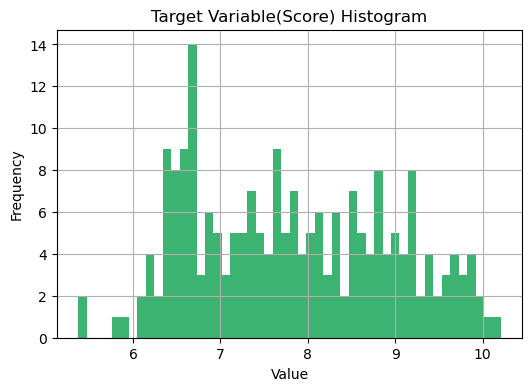

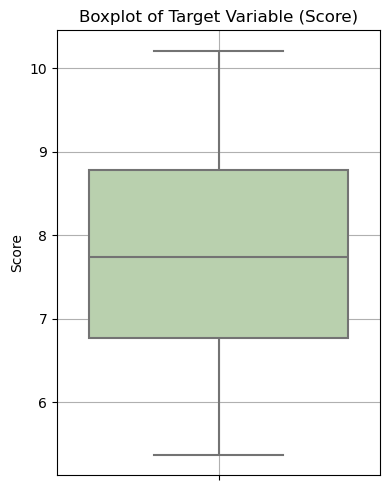

In [21]:
# y 변수 확인 (기본 통계량)
print(y.describe())

# 히스토그램 시각화
plt.figure(figsize=(6, 4))
y.hist(bins=50, color='mediumseagreen')
plt.title("Target Variable(Score) Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 박스플롯 (Seaborn 사용)
plt.figure(figsize=(4, 5))
sns.boxplot(y=y, color="#B7D6A8", linewidth=1.5)

plt.title("Boxplot of Target Variable (Score)")
plt.ylabel("Score")

plt.grid(True)
plt.tight_layout()
plt.show()

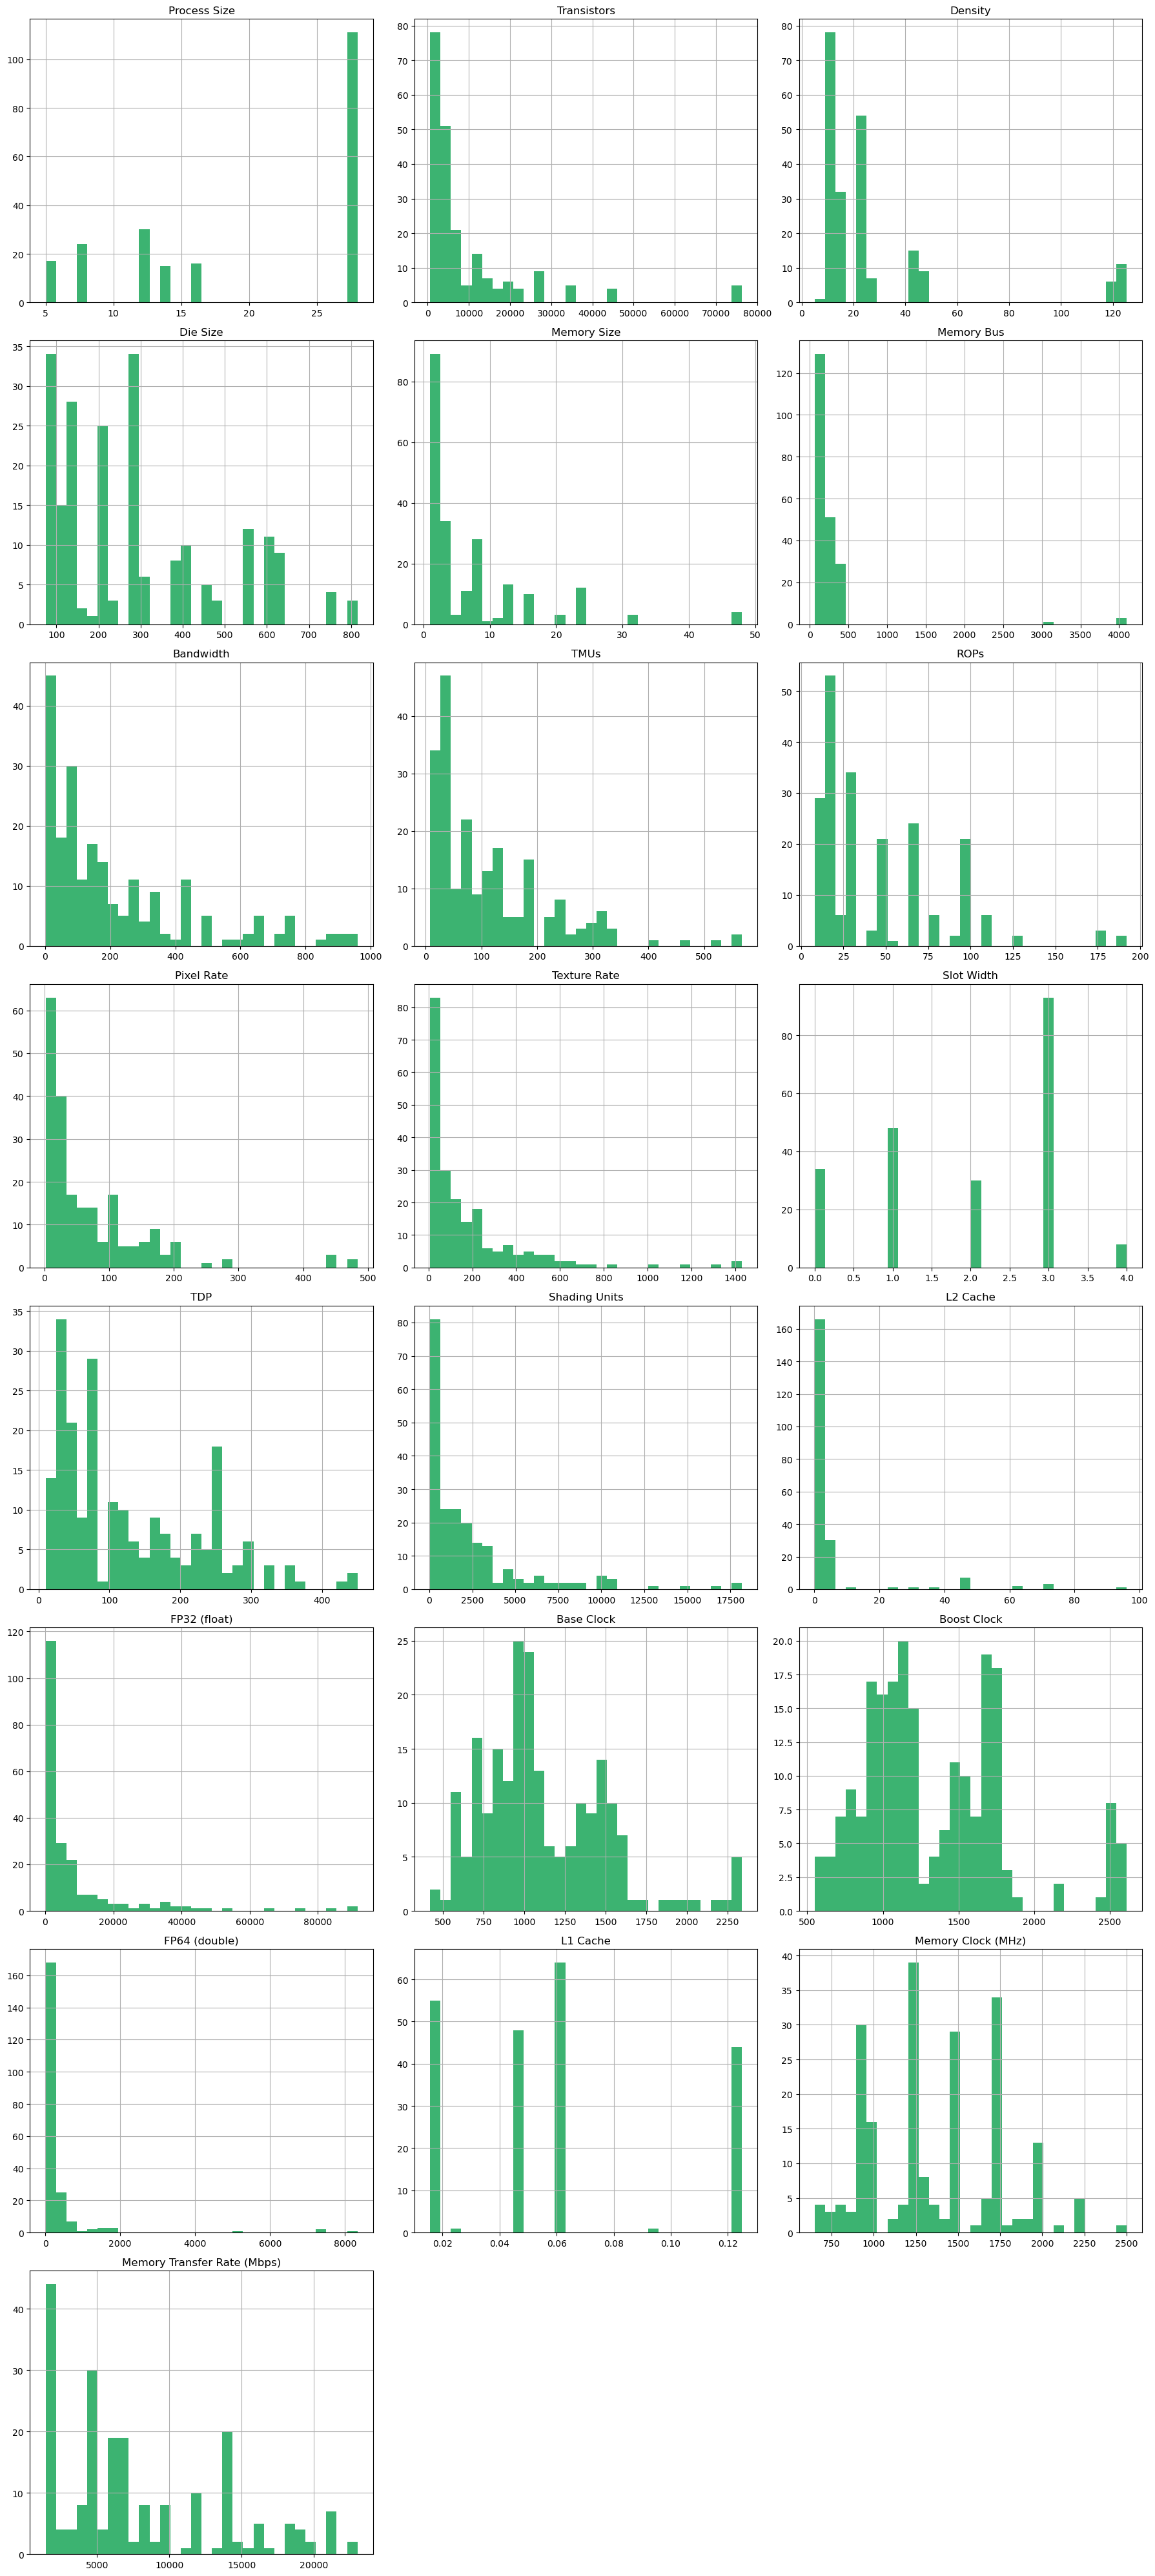

In [22]:
import math

# 타겟 변수와 식별자 제외한 수치형 컬럼만 선택
exclude_columns = ['Model Name', 'Score']
numerical_columns = df.drop(columns=exclude_columns).select_dtypes(include='number').columns.tolist()

# 한 행당 3개씩 히스토그램 출력
cols_per_row = 3
num_cols = len(numerical_columns)
num_rows = math.ceil(num_cols / cols_per_row)

fig, axs = plt.subplots(num_rows, cols_per_row, figsize=(18, 5 * num_rows))
axs = axs.flatten()

for i, col in enumerate(numerical_columns):
    df[col].hist(ax=axs[i], bins=30, color='mediumseagreen')
    axs[i].set_title(col)

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

,Process Size,Transistors,Density,Die Size,Memory Size,Memory Bus,Bandwidth,TMUs,ROPs,Pixel Rate,Texture Rate,Slot Width,TDP,Shading Units,L2 Cache,FP32 (float),Base Clock,Boost Clock,FP64 (double),L1 Cache,Score,Memory Clock (MHz),Memory Transfer Rate (Mbps),Foundry_Samsung,Foundry_TSMC,MemType_DDR3,MemType_GDDR5,MemType_GDDR5X,MemType_GDDR6,MemType_GDDR6X,MemType_HBM2
Process Size,1.000000,-0.662143,-0.730481,-0.390285,-0.566973,-0.147003,-0.604557,-0.520729,-0.589597,-0.660672,-0.611756,-0.523528,-0.394753,-0.624030,-0.500535,-0.614497,-0.653589,-0.859446,-0.217395,-0.777965,-0.738053,-0.556697,-0.846229,-0.500121,0.500121,0.441806,0.467494,-0.065255,-0.657698,-0.399288,-0.104560
Transistors,-0.662143,1.000000,0.869399,0.574626,0.774457,0.195470,0.649216,0.857873,0.854259,0.956744,0.960010,0.521783,0.669200,0.953405,0.896009,0.978633,0.525525,0.769204,0.314958,0.663091,0.924204,0.409974,0.766594,0.088984,-0.088984,-0.286551,-0.380763,-0.012595,0.348804,0.566616,0.098319
Density,-0.730481,0.869399,1.000000,0.267332,0.581667,0.033722,0.478510,0.596822,0.616218,0.772030,0.757393,0.431442,0.431894,0.762019,0.892531,0.824031,0.622836,0.826314,0.155396,0.722691,0.826480,0.433146,0.781174,0.139224,-0.139224,-0.261209,-0.389235,-0.023175,0.384089,0.548818,-0.010858
Die Size,-0.390285,0.574626,0.267332,1.000000,0.714535,0.506742,0.809353,0.863345,0.842071,0.684489,0.692122,0.674366,0.852561,0.670007,0.287834,0.545387,0.242040,0.397182,0.521828,0.320802,0.654553,0.385352,0.518282,0.010357,-0.010357,-0.467065,-0.139201,0.052176,0.305045,0.268165,0.341807
Memory Size,-0.566973,0.774457,0.581667,0.714535,1.000000,0.373481,0.750803,0.844830,0.844616,0.832406,0.839054,0.517684,0.656034,0.818372,0.576385,0.774915,0.367181,0.619511,0.432388,0.543737,0.774907,0.433176,0.594884,0.083943,-0.083943,-0.304469,-0.332442,0.094510,0.405359,0.253923,0.244849
Memory Bus,-0.147003,0.195470,0.033722,0.506742,0.373481,1.000000,0.470127,0.393171,0.400583,0.280332,0.275453,0.251827,0.333447,0.223209,0.048032,0.153529,0.073077,0.107157,0.947099,0.140019,0.233656,-0.109185,-0.053656,-0.068091,0.068091,-0.160891,-0.108461,0.007915,-0.051583,0.023995,0.971727
Bandwidth,-0.604557,0.649216,0.478510,0.809353,0.750803,0.470127,1.000000,0.808886,0.801819,0.727619,0.730074,0.638886,0.735296,0.734355,0.407186,0.639653,0.412824,0.601445,0.492988,0.534894,0.780756,0.440931,0.671632,0.163640,-0.163640,-0.421181,-0.319006,0.084372,0.393464,0.386903,0.337498
TMUs,-0.520729,0.857873,0.596822,0.863345,0.844830,0.393171,0.808886,1.000000,0.947042,0.914770,0.942609,0.658250,0.884627,0.923869,0.647734,0.863337,0.404989,0.603527,0.479064,0.472485,0.870460,0.416737,0.665635,0.031879,-0.031879,-0.391832,-0.240324,0.086546,0.256795,0.472390,0.238177
ROPs,-0.589597,0.854259,0.616218,0.842071,0.844616,0.400583,0.801819,0.947042,1.000000,0.946011,0.916763,0.683583,0.842183,0.901698,0.643085,0.846404,0.440849,0.665461,0.448417,0.544728,0.872018,0.468072,0.687697,0.078723,-0.078723,-0.426060,-0.243626,0.105241,0.296251,0.448572,0.246546
Pixel Rate,-0.660672,0.956744,0.772030,0.684489,0.832406,0.280332,0.727619,0.914770,0.946011,1.000000,0.981262,0.615790,0.762648,0.948348,0.810741,0.953702,0.559833,0.789217,0.374622,0.619734,0.926415,0.471030,0.754485,0.066455,-0.066455,-0.348123,-0.333424,0.081381,0.323615,0.522354,0.157350


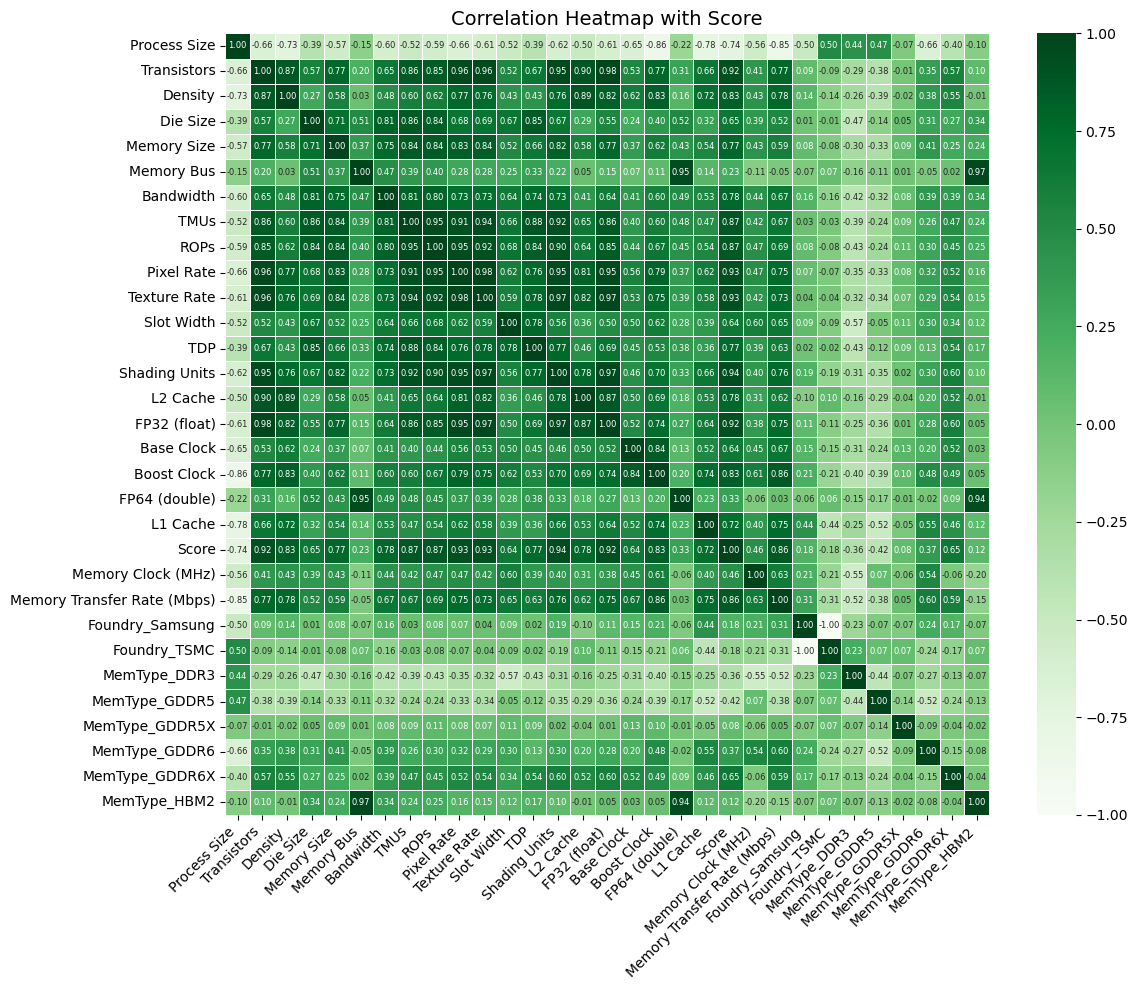

,Feature,Correlation with Score
0,Shading Units,0.936623
1,Texture Rate,0.926727
2,Pixel Rate,0.926415
3,Transistors,0.924204
4,FP32 (float),0.919986
5,ROPs,0.872018
6,TMUs,0.870460
7,Memory Transfer Rate (Mbps),0.861761
8,Density,0.826480
9,Boost Clock,0.825196


In [23]:
# 수치형 변수들 간 상관계수 행렬
corr = df.corr(numeric_only=True)
display(corr)

# Score 기준 상관계수만 따로 정리 (정렬)
target_corr = corr["Score"].drop("Score").sort_values(ascending=False)

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr, 
            cmap='Greens',        # 초록 계열
            annot=True,           
            fmt=".2f",            
            linewidths=0.5, 
            annot_kws={"size": 6}
           )
plt.title("Correlation Heatmap with Score", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Score와의 상관계수 테이블 출력
target_corr_df = target_corr.reset_index()
target_corr_df.columns = ['Feature', 'Correlation with Score']
display(target_corr_df)

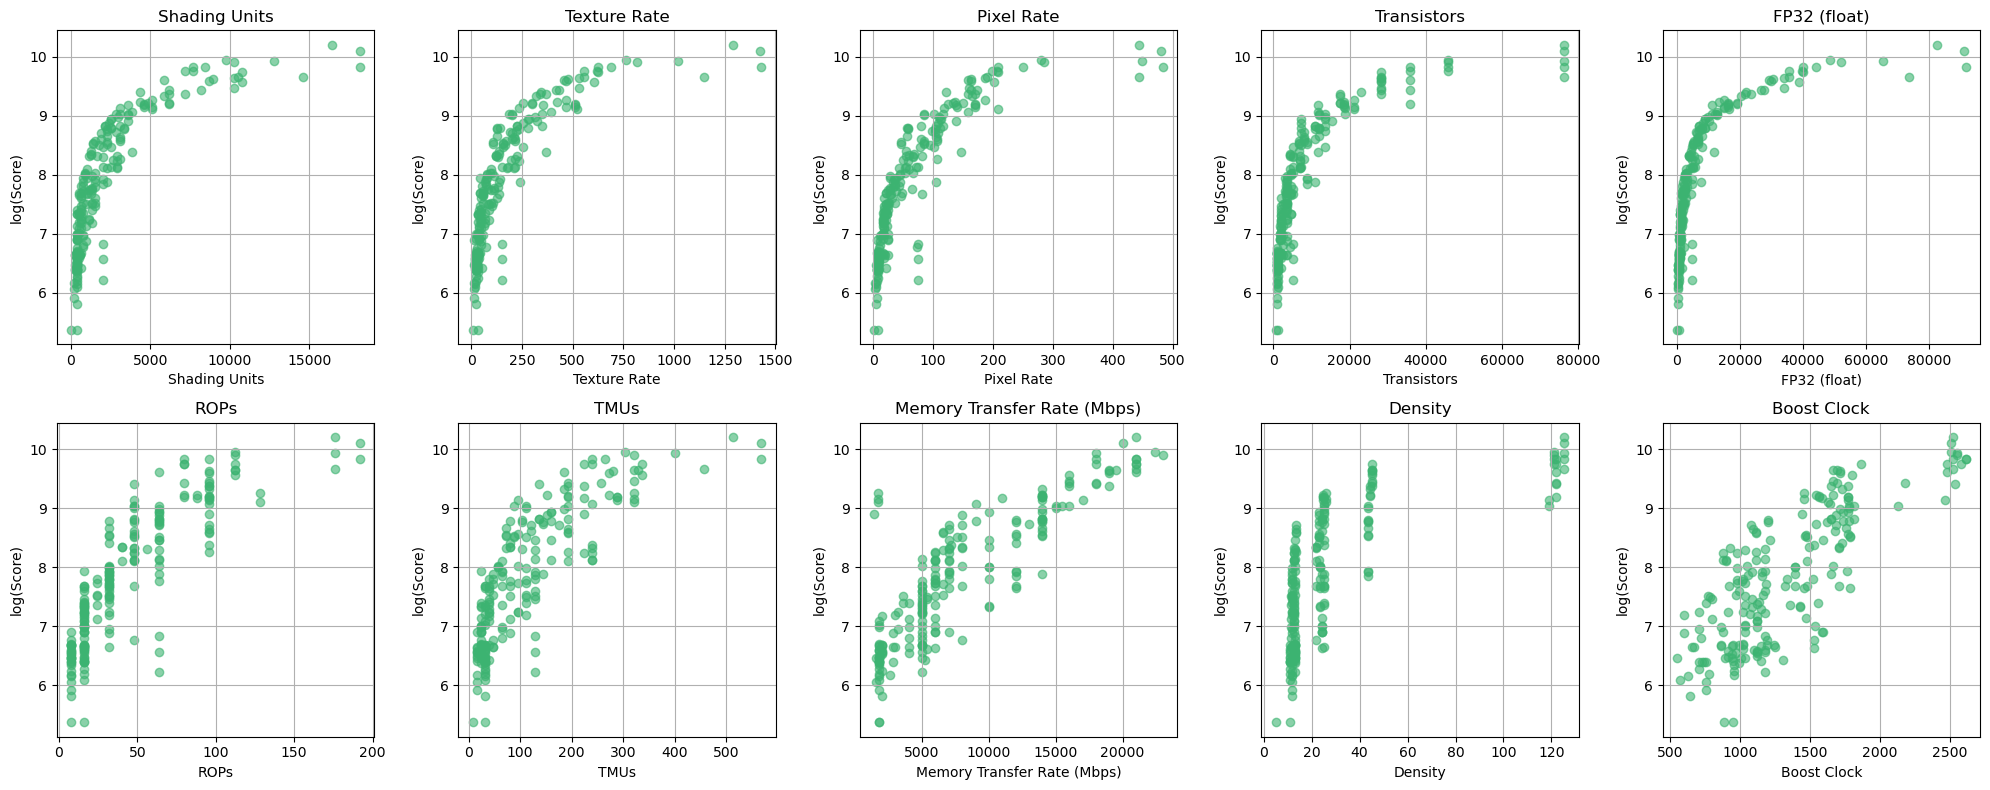

In [24]:
# 양의 상관관계 상위 10개 변수
top_positive = target_corr.head(10).index.tolist()

# 스캐터 플롯 (2행 5열)
plt.figure(figsize=(20, 8))
for i, col in enumerate(top_positive):
    plt.subplot(2, 5, i + 1)
    plt.scatter(df[col], y, alpha=0.6, color='mediumseagreen')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("log(Score)")
    plt.grid(True)

plt.tight_layout()
plt.show()

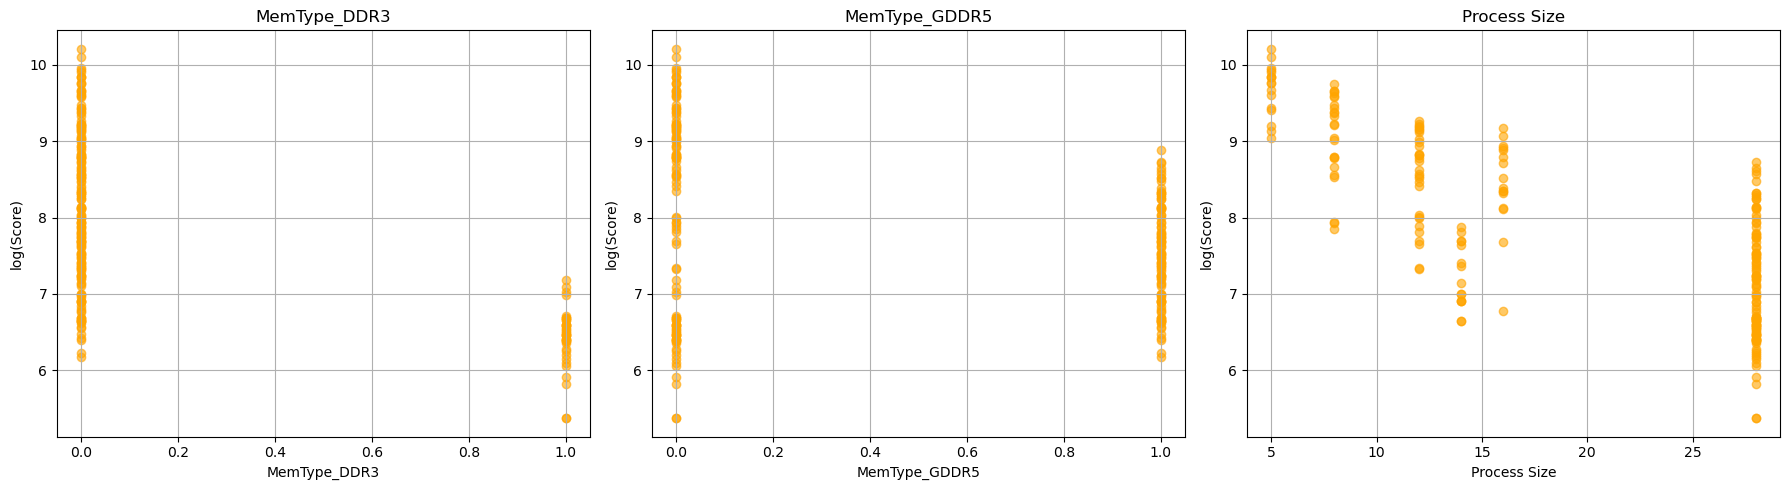

In [25]:
# 음의 상관관계 하위 3개 변수
bottom_negative = target_corr.tail(3).index.tolist()

# 스캐터 플롯 (1행 3열)
plt.figure(figsize=(18, 5))
for i, col in enumerate(bottom_negative):
    plt.subplot(1, 3, i + 1)
    plt.scatter(df[col], y, alpha=0.6, color='orange')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("log(Score)")
    plt.grid(True)

plt.tight_layout()
plt.show()

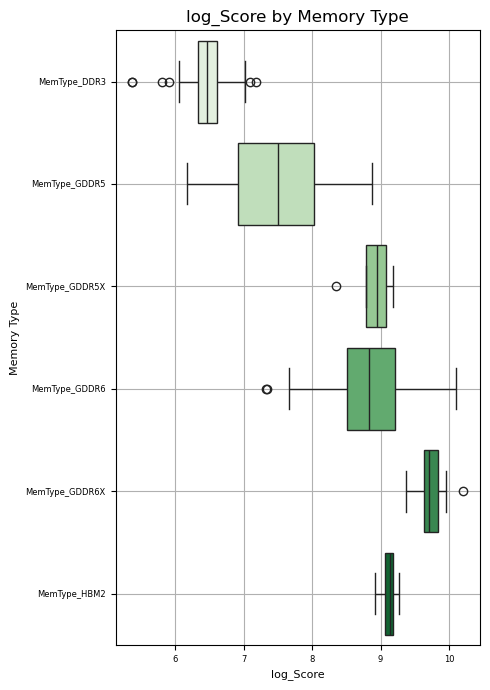

In [26]:
# 메모리 타입 관련 컬럼 추출
memtype_cols = [col for col in X.columns if col.startswith('MemType_')]

# log(FP32)와 메모리 타입 정보 결합
df_box = df[memtype_cols].copy()
df_box["log_Score"] = y  # log1p 된 타겟 변수 사용

# melt로 long-format 변환
df_melted = df_box.melt(id_vars=['log_Score'], 
                        value_vars=memtype_cols, 
                        var_name='MemType', 
                        value_name='IsType')
df_melted = df_melted[df_melted["IsType"] == 1]

# 초록 계열 그라데이션 팔레트
mem_palette = sns.color_palette("Greens", n_colors=df_melted['MemType'].nunique())
palette_dict = dict(zip(df_melted['MemType'].unique(), mem_palette))

# 박스플롯 시각화(가로 방향)
plt.figure(figsize=(5, 7))
sns.boxplot(data=df_melted, y='MemType', x='log_Score', hue='MemType', 
            palette=palette_dict, dodge=False, legend=False)  # hue 지정 + legend 제거

# 폰트 크기 조정
plt.title("log_Score by Memory Type", fontsize=12)
plt.xlabel("log_Score", fontsize=8)
plt.ylabel("Memory Type", fontsize=8)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.grid(True)
plt.tight_layout()
plt.show()

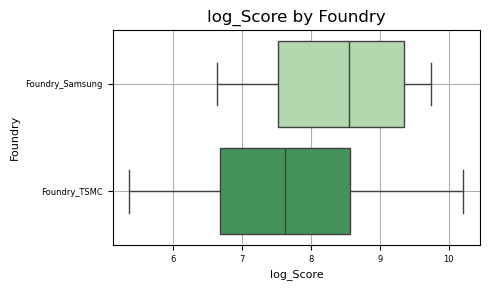

In [27]:
# Foundry 관련 컬럼 지정
foundry_cols = ['Foundry_Samsung', 'Foundry_TSMC']

# 박스플롯용 데이터프레임 구성
df_box_foundry = df[foundry_cols].copy()
df_box_foundry["log_Score"] = y

# melt 변환
df_melted_foundry = df_box_foundry.melt(id_vars=['log_Score'],
                                        value_vars=foundry_cols,
                                        var_name='Foundry',
                                        value_name='IsType')
df_melted_foundry = df_melted_foundry[df_melted_foundry["IsType"] == 1]

# 노랑 계열 그라데이션 팔레트 생성
foundry_palette = sns.color_palette("Greens", n_colors=df_melted_foundry['Foundry'].nunique())
palette_dict_foundry = dict(zip(df_melted_foundry['Foundry'].unique(), foundry_palette))

# 박스플롯 시각화
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_melted_foundry, y='Foundry', x='log_Score', hue='Foundry',
            palette=palette_dict_foundry, dodge=False, legend=False)

# 폰트 크기 조정
plt.title("log_Score by Foundry", fontsize=12)
plt.xlabel("log_Score", fontsize=8)
plt.ylabel("Foundry", fontsize=8)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# 연속형 변수 명시적 설정 (원핫 인코딩 및 오디너리 인코딩된 값은 제외)
continuous_columns = [
    'Process Size', 'Transistors', 'Density', 'Die Size', 'Memory Size', 
    'Memory Bus', 'Bandwidth', 'TMUs', 'ROPs', 'Pixel Rate', 'Texture Rate', 
    'TDP', 'Shading Units', 'L2 Cache', 'FP32 (float)', 'Base Clock', 
    'Boost Clock', 'FP64 (double)', 'L1 Cache', 'Memory Clock (MHz)', 
    'Memory Transfer Rate (Mbps)'
]

# StandardScaler로 연속형 변수만 표준화
scaler = StandardScaler()

# 표준화 X
X_scaled = X.copy()
X_scaled[continuous_columns] = scaler.fit_transform(X_scaled[continuous_columns])

# 데이터 확인
display(X.head())
display(X_scaled.head())

X_scaled.to_csv('확인용_temp_scaled.csv', index=False)

,Process Size,Transistors,Density,Die Size,Memory Size,Memory Bus,Bandwidth,TMUs,ROPs,Pixel Rate,Texture Rate,Slot Width,TDP,Shading Units,L2 Cache,FP32 (float),Base Clock,Boost Clock,FP64 (double),L1 Cache,Memory Clock (MHz),Memory Transfer Rate (Mbps),Foundry_Samsung,Foundry_TSMC,MemType_DDR3,MemType_GDDR5,MemType_GDDR5X,MemType_GDDR6,MemType_GDDR6X,MemType_HBM2
717,28.0,1270.0,10.8,118.0,2.0,128.0,28.8,32.0,16.0,5.672,22.69,0,32.0,384.0,0.250,544.5,624.0,709.0,22.69,0.015625,900.0,1800.0,False,True,True,False,False,False,False,False
718,28.0,1270.0,10.8,118.0,1.0,128.0,28.8,32.0,16.0,4.560,18.24,0,20.0,384.0,0.250,437.8,500.0,570.0,18.24,0.015625,900.0,1800.0,False,True,True,False,False,False,False,False
721,28.0,1270.0,10.8,118.0,2.0,128.0,28.8,32.0,16.0,6.240,24.96,0,32.0,384.0,0.250,599.0,709.0,780.0,24.96,0.015625,900.0,1800.0,False,True,True,False,False,False,False,False
722,28.0,1270.0,10.8,118.0,1.0,128.0,28.8,32.0,16.0,7.600,30.40,0,45.0,384.0,0.250,729.6,835.0,950.0,30.40,0.015625,900.0,1800.0,False,True,True,False,False,False,False,False
728,28.0,2540.0,11.5,221.0,2.0,192.0,144.2,80.0,24.0,20.640,82.56,3,140.0,960.0,0.375,1981.0,980.0,1032.0,82.56,0.015625,1502.0,6000.0,False,True,False,True,False,False,False,False


,Process Size,Transistors,Density,Die Size,Memory Size,Memory Bus,Bandwidth,TMUs,ROPs,Pixel Rate,Texture Rate,Slot Width,TDP,Shading Units,L2 Cache,FP32 (float),Base Clock,Boost Clock,FP64 (double),L1 Cache,Memory Clock (MHz),Memory Transfer Rate (Mbps),Foundry_Samsung,Foundry_TSMC,MemType_DDR3,MemType_GDDR5,MemType_GDDR5X,MemType_GDDR6,MemType_GDDR6X,MemType_HBM2
717,0.918808,-0.592412,-0.582189,-0.89269,-0.618973,-0.249944,-0.835141,-0.771439,-0.764056,-0.760250,-0.667410,0,-0.948644,-0.639305,-0.377066,-0.533816,-1.267997,-1.312703,-0.311665,-1.165409,-1.204280,-1.087709,False,True,True,False,False,False,False,False
718,0.918808,-0.592412,-0.582189,-0.89269,-0.732728,-0.249944,-0.835141,-0.771439,-0.764056,-0.773235,-0.686156,0,-1.068621,-0.639305,-0.377066,-0.540906,-1.589497,-1.607440,-0.316113,-1.165409,-1.204280,-1.087709,False,True,True,False,False,False,False,False
721,0.918808,-0.592412,-0.582189,-0.89269,-0.618973,-0.249944,-0.835141,-0.771439,-0.764056,-0.753617,-0.657848,0,-0.948644,-0.639305,-0.377066,-0.530194,-1.047614,-1.162154,-0.309396,-1.165409,-1.204280,-1.087709,False,True,True,False,False,False,False,False
722,0.918808,-0.592412,-0.582189,-0.89269,-0.732728,-0.249944,-0.835141,-0.771439,-0.764056,-0.737736,-0.634932,0,-0.818669,-0.639305,-0.377066,-0.521515,-0.720929,-0.801684,-0.303958,-1.165409,-1.204280,-1.087709,False,True,True,False,False,False,False,False
728,0.918808,-0.502371,-0.558525,-0.35621,-0.618973,-0.124530,-0.332127,-0.318152,-0.551874,-0.585460,-0.415212,3,0.131148,-0.459599,-0.368569,-0.438353,-0.344981,-0.627811,-0.251816,-1.165409,0.327178,-0.344299,False,True,False,True,False,False,False,False


In [29]:
# VIF 계산을 위해 bool → float 변환
X_scaled = X_scaled.astype(float)

# 더미 트랩 문제 해결 : 같은 One-hot 변수 중 하나 제거, 보편적으로 빈도 수가 더 높은 것을 거거
X_scaled = X_scaled.drop(columns=["Foundry_TSMC", "MemType_GDDR5"])

In [30]:
# 복사본으로 작업
X_reduced = X_scaled.copy()
iteration = 0
max_vif = float('inf')

# 초기 VIF 계산 및 출력
X_const_initial = add_constant(X_reduced)
vif_df_initial = pd.DataFrame()
vif_df_initial["feature"] = X_const_initial.columns
vif_df_initial["VIF"] = [variance_inflation_factor(X_const_initial.values, i) for i in range(X_const_initial.shape[1])]
vif_df_initial = vif_df_initial[vif_df_initial["feature"] != "const"]

print("📌 초기 VIF 값:")
display(vif_df_initial.sort_values("VIF", ascending=False))

while True:
    # 상수항 추가
    X_const = add_constant(X_reduced)

    # VIF 계산
    vif_df = pd.DataFrame()
    vif_df["feature"] = X_const.columns
    vif_df["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

    # 'const' 제외
    vif_df = vif_df[vif_df["feature"] != "const"]

    # 최대 VIF 찾기
    max_vif_row = vif_df.sort_values("VIF", ascending=False).iloc[0]
    max_vif = max_vif_row["VIF"]
    max_feature = max_vif_row["feature"]

    # 종료 조건
    if max_vif <= 10:
        break

    # 변수 제거
    X_reduced = X_reduced.drop(columns=[max_feature])
    iteration += 1
    print(f"🔁 {iteration}회차 제거: '{max_feature}' (VIF: {max_vif:.2f})")

# 최종 VIF 표 출력
X_const_final = add_constant(X_reduced)
vif_df_final = pd.DataFrame()
vif_df_final["feature"] = X_const_final.columns
vif_df_final["VIF"] = [variance_inflation_factor(X_const_final.values, i) for i in range(X_const_final.shape[1])]
vif_df_final = vif_df_final[vif_df_final["feature"] != "const"]

print("\n📊 최종 VIF 값:")
display(vif_df_final)

# 결과 출력
print("\n✅ 다중공선성 제거 완료!")
print(f"총 제거 횟수: {iteration}")
print("남은 변수 목록:")
display(X_reduced.info())

📌 초기 VIF 값:


,feature,VIF
16,FP32 (float),1019.823718
11,Texture Rate,805.739994
14,Shading Units,668.103152
22,Memory Transfer Rate (Mbps),437.014353
8,TMUs,420.349841
10,Pixel Rate,367.797686
9,ROPs,158.424622
2,Transistors,156.597292
27,MemType_GDDR6X,149.426077
26,MemType_GDDR6,108.184926


🔁 1회차 제거: 'FP32 (float)' (VIF: 1019.82)
🔁 2회차 제거: 'Memory Transfer Rate (Mbps)' (VIF: 433.08)
🔁 3회차 제거: 'Pixel Rate' (VIF: 349.06)
🔁 4회차 제거: 'TMUs' (VIF: 168.33)
🔁 5회차 제거: 'Texture Rate' (VIF: 97.17)
🔁 6회차 제거: 'MemType_HBM2' (VIF: 76.46)
🔁 7회차 제거: 'Transistors' (VIF: 70.77)
🔁 8회차 제거: 'ROPs' (VIF: 23.96)
🔁 9회차 제거: 'Boost Clock' (VIF: 21.86)
🔁 10회차 제거: 'Shading Units' (VIF: 17.78)
🔁 11회차 제거: 'Process Size' (VIF: 16.81)
🔁 12회차 제거: 'Memory Bus' (VIF: 13.91)
🔁 13회차 제거: 'Density' (VIF: 12.94)
🔁 14회차 제거: 'TDP' (VIF: 10.46)

📊 최종 VIF 값:


,feature,VIF
1,Die Size,5.597275
2,Memory Size,4.178869
3,Bandwidth,5.012941
4,Slot Width,3.210596
5,L2 Cache,3.144665
6,Base Clock,2.641314
7,FP64 (double),2.864249
8,L1 Cache,4.298976
9,Memory Clock (MHz),4.864669
10,Foundry_Samsung,1.804734



✅ 다중공선성 제거 완료!
총 제거 횟수: 14
남은 변수 목록:
<class 'pandas.core.frame.DataFrame'>
Index: 213 entries, 717 to 1416
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Die Size            213 non-null    float64
 1   Memory Size         213 non-null    float64
 2   Bandwidth           213 non-null    float64
 3   Slot Width          213 non-null    float64
 4   L2 Cache            213 non-null    float64
 5   Base Clock          213 non-null    float64
 6   FP64 (double)       213 non-null    float64
 7   L1 Cache            213 non-null    float64
 8   Memory Clock (MHz)  213 non-null    float64
 9   Foundry_Samsung     213 non-null    float64
 10  MemType_DDR3        213 non-null    float64
 11  MemType_GDDR5X      213 non-null    float64
 12  MemType_GDDR6       213 non-null    float64
 13  MemType_GDDR6X      213 non-null    float64
dtypes: float64(14)
memory usage: 25.0 KB


None

In [31]:
import statsmodels.api as sm

# 복사본으로 시작
X_pval = X_reduced.copy()
y_target = y.copy()  # y는 네가 회귀에서 쓰는 타겟 변수

iteration = 0

while True:
    # 상수항 추가
    X_const = add_constant(X_pval)

    # OLS 회귀 적합
    model = sm.OLS(y_target, X_const)
    results = model.fit()

    # const 제외한 p-value만 추출
    p_values = results.pvalues.drop("const")

    # 가장 큰 p-value와 해당 변수
    max_pval = p_values.max()
    max_feature = p_values.idxmax()

    # 종료 조건
    if max_pval <= 0.05:
        break

    # 변수 제거
    X_pval = X_pval.drop(columns=[max_feature])
    iteration += 1
    print(f"🔁 {iteration}회차 제거: '{max_feature}' (p-value: {max_pval:.4f})")

# 최종 결과 요약
print("\n✅ 유의하지 않은 변수 제거 완료!")
print(f"총 제거 횟수: {iteration}")
print("남은 변수 목록:")
print(X_pval.columns.tolist())

# 최종 모델 요약 출력
final_model = sm.OLS(y_target, add_constant(X_pval)).fit()
print("\n📊 최종 모델 summary:")
print(final_model.summary())

🔁 1회차 제거: 'Memory Size' (p-value: 0.7732)
🔁 2회차 제거: 'Foundry_Samsung' (p-value: 0.6820)
🔁 3회차 제거: 'FP64 (double)' (p-value: 0.1659)

✅ 유의하지 않은 변수 제거 완료!
총 제거 횟수: 3
남은 변수 목록:
['Die Size', 'Bandwidth', 'Slot Width', 'L2 Cache', 'Base Clock', 'L1 Cache', 'Memory Clock (MHz)', 'MemType_DDR3', 'MemType_GDDR5X', 'MemType_GDDR6', 'MemType_GDDR6X']

📊 최종 모델 summary:
                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     216.1
Date:                Tue, 08 Apr 2025   Prob (F-statistic):          6.74e-105
Time:                        21:49:23   Log-Likelihood:                -56.443
No. Observations:                 213   AIC:                             136.9
Df Residuals:                     201   BIC:                             177.2
Df Mode

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from math import sqrt
import numpy as np

# 🎯 X, y 설정
X = X_pval
y = y_target  # 예: df["Score"]

# 🧪 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🧠 선형 회귀 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 🔮 예측 (log 스케일)
pred_train_log = model.predict(X_train)
pred_test_log = model.predict(X_test)

# 🔁 log1p → 복원
y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)
pred_train_actual = np.expm1(pred_train_log)
pred_test_actual = np.expm1(pred_test_log)

# 📊 성능 평가
train_r2 = r2_score(y_train_actual, pred_train_actual)
test_r2 = r2_score(y_test_actual, pred_test_actual)
train_rmse = sqrt(mean_squared_error(y_train_actual, pred_train_actual))
test_rmse = sqrt(mean_squared_error(y_test_actual, pred_test_actual))
mae = mean_absolute_error(y_test_actual, pred_test_actual)

# 결과 출력
print("✅ 회귀 모델 성능 평가, 복원된 Score 기준")
print(f"Train R²        : {train_r2:.4f}")
print(f"Test R²         : {test_r2:.4f}")
print(f"Train RMSE      : {train_rmse:.2f}")
print(f"Test RMSE       : {test_rmse:.2f}")
print(f"Test MAE        : {mae:.2f}")

✅ 회귀 모델 성능 평가, 복원된 Score 기준
Train R²        : 0.9165
Test R²         : 0.8671
Train RMSE      : 1424.67
Test RMSE       : 2237.03
Test MAE        : 1237.83


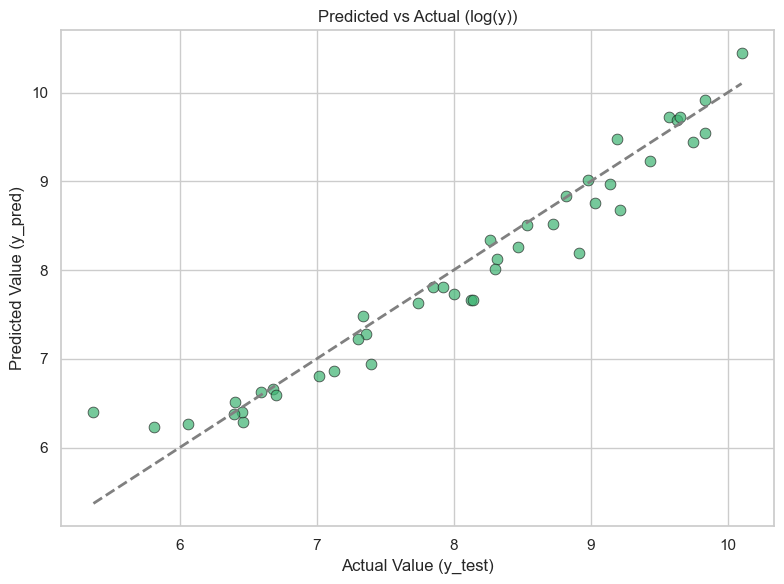

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# 스타일 설정
sns.set(style="whitegrid")

# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=pred_test_log, color="mediumseagreen", s=60, edgecolor='k', alpha=0.7)

# 완벽 예측 대각선
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'gray', linestyle='--', linewidth=2)

# 라벨 및 제목
plt.xlabel("Actual Value (y_test)")
plt.ylabel("Predicted Value (y_pred)")
plt.title("Predicted vs Actual (log(y))")
plt.tight_layout()
plt.show()

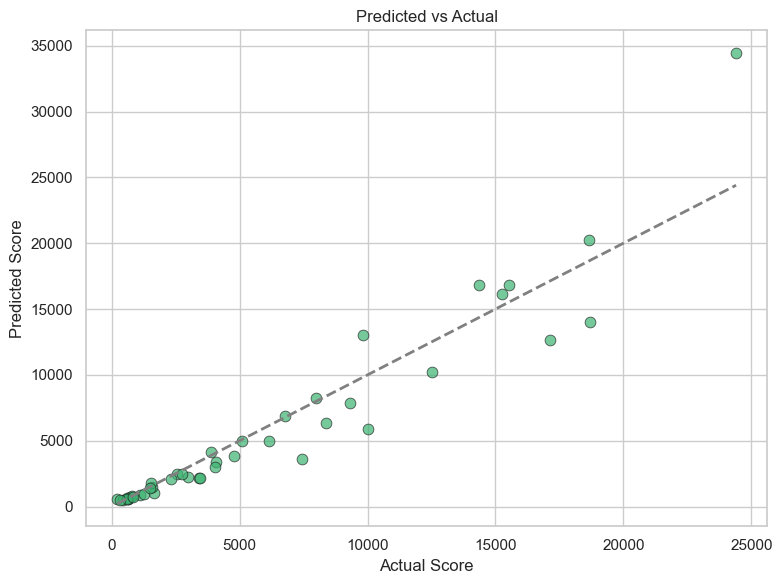

In [34]:
# 스타일 설정
sns.set(style="whitegrid")

# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_actual, y=pred_test_actual, color="mediumseagreen", s=60, edgecolor='k', alpha=0.7)

# 완벽 예측 대각선
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'gray', linestyle='--', linewidth=2)

# 라벨 및 제목
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

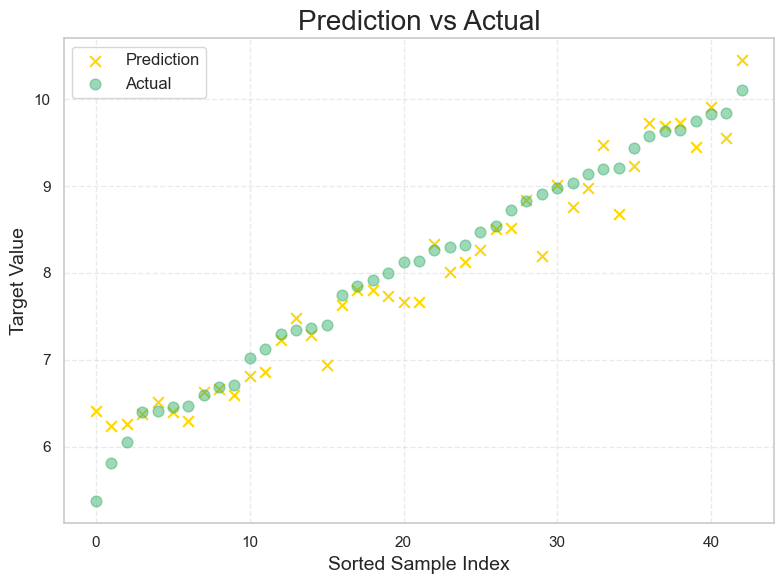

In [35]:
df = pd.DataFrame({'actual': y_test, 'prediction': pred_test_log})
df = df.sort_values(by='actual').reset_index(drop=True)

# 플롯
plt.figure(figsize=(8, 6))
plt.scatter(df.index, df['prediction'], marker='x', color='gold', label='Prediction', s=60)
plt.scatter(df.index, df['actual'], alpha=0.5, marker='o', color='mediumseagreen', label='Actual', s=60)

# 스타일 설정
plt.title("Prediction vs Actual", fontsize=20)
plt.xlabel("Sorted Sample Index", fontsize=14)
plt.ylabel("Target Value", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

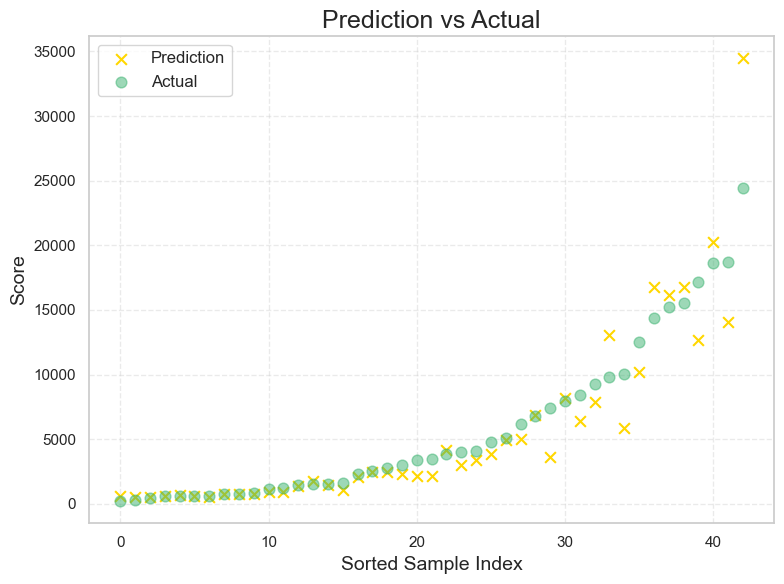

In [36]:
# 정렬용 데이터프레임
df = pd.DataFrame({'actual': y_test_actual, 'prediction': pred_test_actual})
df = df.sort_values(by='actual').reset_index(drop=True)

# 플롯
plt.figure(figsize=(8, 6))
plt.scatter(df.index, df['prediction'], marker='x', color='gold', label='Prediction', s=60)
plt.scatter(df.index, df['actual'], alpha=0.5, marker='o', color='mediumseagreen', label='Actual', s=60)

# 스타일 설정
plt.title("Prediction vs Actual", fontsize=18)
plt.xlabel("Sorted Sample Index", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

,feature,coefficient
3,L2 Cache,0.085268
2,Slot Width,0.117859
4,Base Clock,0.121056
1,Bandwidth,0.133145
5,L1 Cache,0.168743
6,Memory Clock (MHz),0.213642
7,MemType_DDR3,-0.223948
9,MemType_GDDR6,0.287173
0,Die Size,0.315984
10,MemType_GDDR6X,0.658212


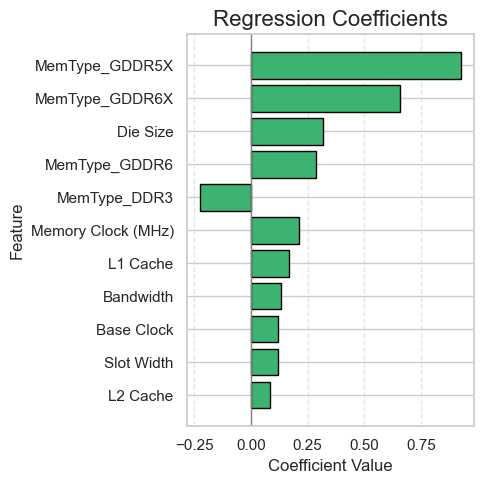

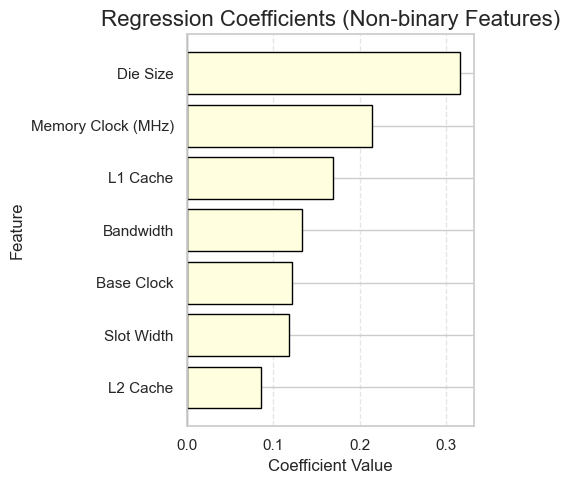

In [43]:
# 📋 전체 회귀 계수 표
display(coef_df)

# 회귀 계수 추출
coef_df = pd.DataFrame({
    "feature": X_pval.columns,
    "coefficient": model.coef_
}).sort_values(by="coefficient", key=abs, ascending=True)  # 절댓값 기준 정렬

# 시각화
plt.figure(figsize=(5, 5))
bars = plt.barh(coef_df["feature"], coef_df["coefficient"], color="mediumseagreen", edgecolor="black")
plt.axvline(0, color='gray', linewidth=1)

plt.title("Regression Coefficients", fontsize=16)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# -------------------------------------------

# 바이너리 변수 제거
binary_features = [col for col in X_pval.columns if X_pval[col].nunique() == 2]
non_binary_mask = ~X_pval.columns.isin(binary_features)

# 비바이너리 변수 회귀 계수 추출
coef_df_non_binary = pd.DataFrame({
    "feature": X_pval.columns[non_binary_mask],
    "coefficient": model.coef_[non_binary_mask]
}).sort_values(by="coefficient", key=abs, ascending=True)

# 시각화
plt.figure(figsize=(5, 5))
bars = plt.barh(coef_df_non_binary["feature"], coef_df_non_binary["coefficient"],
                color="lightyellow", edgecolor="black")
plt.axvline(0, color='gray', linewidth=1)

plt.title("Regression Coefficients (Non-binary Features)", fontsize=16)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [38]:
# 회귀식 출력
print("📘 최종 회귀식!:")
terms = [f"{coef:.4f}·{name}" for name, coef in zip(X_pval.columns, model.coef_)]
equation = " + ".join(terms)
equation = f"y = {model.intercept_:.4f} + " + equation
print(equation)

📘 최종 회귀식!:
y = 7.4877 + 0.3160·Die Size + 0.1331·Bandwidth + 0.1179·Slot Width + 0.0853·L2 Cache + 0.1211·Base Clock + 0.1687·L1 Cache + 0.2136·Memory Clock (MHz) + -0.2239·MemType_DDR3 + 0.9244·MemType_GDDR5X + 0.2872·MemType_GDDR6 + 0.6582·MemType_GDDR6X


In [39]:
from math import exp

# 회귀식을 텍스트로 구성
terms = [f"{coef:.4f}·{name}" for name, coef in zip(X_pval.columns, model.coef_)]
linear_part = " + ".join(terms)
intercept = model.intercept_

# 최종 식
equation = f"Score = exp({intercept:.4f} + {linear_part}) - 1"
print("📘 복원된 실제 단위 회귀식:")
print(equation)

📘 복원된 실제 단위 회귀식:
Score = exp(7.4877 + 0.3160·Die Size + 0.1331·Bandwidth + 0.1179·Slot Width + 0.0853·L2 Cache + 0.1211·Base Clock + 0.1687·L1 Cache + 0.2136·Memory Clock (MHz) + -0.2239·MemType_DDR3 + 0.9244·MemType_GDDR5X + 0.2872·MemType_GDDR6 + 0.6582·MemType_GDDR6X) - 1
